![](img/banner.png)
%%HTML
<script src="require.js"></script>

# Random Projection: Theory and Implementation

**Mahmood Amintoosi, Fall 2025**
Computer Science Dept, Ferdowsi University of Mashhad


## 1. Introduction: Why Random Projection?

In the previous section, we explored the weird properties of high-dimensional spaces. We learned that as dimensions increase, data becomes sparse, and distance-based methods (like k-NN) struggle. This is the **Curse of Dimensionality**.

To solve this, we often use **Dimensionality Reduction**. The most famous method is **PCA (Principal Component Analysis)**, which finds the "best" axes to preserve variance. However, PCA has a major drawback:
* **It is computationally expensive:** Calculating the covariance matrix and its eigenvectors takes a long time for very large datasets ($O(d^2 n)$ or $O(d^3)$).

**Random Projection (RP)** offers a surprising alternative:
Instead of finding the "best" axes, we simply project the data onto **random** axes!
* It is incredibly fast.
* It is data-independent (you don't need to see the data to build the projection matrix).
* It preserves distances remarkably well.

---

## 2. Foundation: Orthogonality in High Dimensions

*Recap from High-Dimensional Geometry:*

Why does projecting onto random vectors work? The answer lies in the geometry of high-dimensional spaces.
As we saw in **Foundations of Data Science (Blum et al.)**, if we generate random vectors from a Gaussian distribution in high dimensions ($d \to \infty$), they have a unique property:

> **"Random vectors in high dimensions are nearly orthogonal to each other."**

If you pick $k$ random vectors $r_1, r_2, \dots, r_k$ in a high-dimensional space, they effectively form a new, nearly orthogonal coordinate system. Projecting data onto these vectors is like taking a "snapshot" of the data from $k$ different random angles.


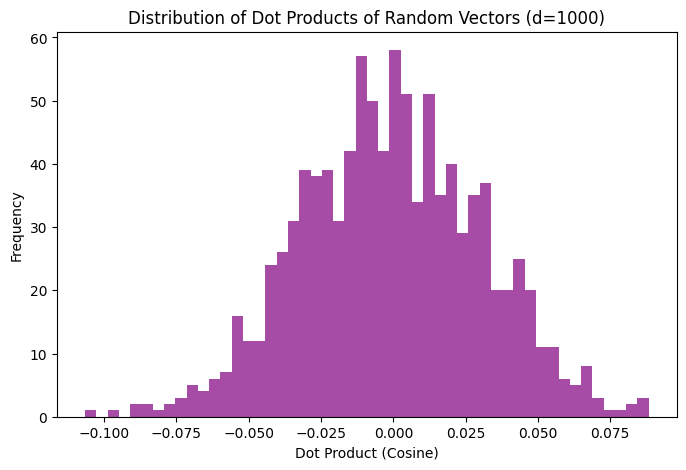

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Demonstration: Dot product of random vectors (Orthogonality check)
d = 1000 # High dimension
n_vectors = 1000

# Generate random vectors (Standard Normal)
R = np.random.randn(n_vectors, d)

# Normalize them to unit length
R_normalized = R / np.linalg.norm(R, axis=1, keepdims=True)

# Compute dot products between the first vector and all others
# Since they are unit vectors, dot product = cosine similarity
dot_products = R_normalized[0] @ R_normalized[1:].T

plt.figure(figsize=(8, 5))
plt.hist(dot_products, bins=50, color='purple', alpha=0.7)
plt.title(f"Distribution of Dot Products of Random Vectors (d={d})")
plt.xlabel("Dot Product (Cosine)")
plt.ylabel("Frequency")
plt.show()


**Observation:** The dot products cluster tightly around **0**. This confirms that random directions are perpendicular (orthogonal) to each other.

-----

## 3\. The Theory: Johnson-Lindenstrauss Lemma

The core theoretical justification for Random Projection is the **Johnson-Lindenstrauss (JL) Lemma**.

It states, simply:

> Points in a high-dimensional space can be mapped into a lower-dimensional space of dimension $k$ such that the **pairwise distances** between the points are nearly preserved.

Mathematically, for any two data points $x$ and $y$:
$$ (1 - \epsilon) ||x - y||^2 \le ||f(x) - f(y)||^2 \le (1 + \epsilon) ||x - y||^2 $$

Where:

  * $f(\cdot)$ is the projection function.
  * $\epsilon$ is the tolerance for distortion (error).

**Key Insight:** The required lower dimension $k$ does **not** depend on the original dimension $d$. It only depends on the number of samples $n$ and the error $\epsilon$:
$$ k \ge \frac{4 \ln(n)}{\epsilon^2 / 2 - \epsilon^3 / 3} $$

This means we can reduce a 1,000,000-dimensional text dataset to a few hundred dimensions just as easily as a 10,000-dimensional one, provided the number of samples $n$ is the same.

-----

## 4\. Types of Random Matrices

In practice, we project data $X$ (shape $n \times d$) into a lower dimension $k$ using a random matrix $R$ (shape $d \times k$):
$$ X_{new} = \frac{1}{\sqrt{k}} X \cdot R $$
*(The scaling factor $1/\sqrt{k}$ is to maintain the expected length of vectors).*

There are two main ways to generate $R$:

### A. Gaussian Random Projection

The elements of the matrix $R$ are drawn from a Normal distribution $N(0, 1)$. This is the classic approach directly following the JL Lemma.

### B. Sparse Random Projection (Achlioptas)

Generating a huge matrix of float numbers is slow. **Dimitris Achlioptas** showed that we can use a much simpler, sparse matrix. The elements $r_{ij}$ are drawn from:

$$
r_{ij} = \begin{cases} 
+\sqrt{s} & \text{with prob } \frac{1}{2s} \\
0 & \text{with prob } 1 - \frac{1}{s} \\
-\sqrt{s} & \text{with prob } \frac{1}{2s}
\end{cases}
$$Usually, $s=3$. This means the matrix is mostly zeros ($\approx 66\%$), with some $+1$ and $-1$.

* **Benefit:** Much faster matrix multiplication and less memory usage.

-----

## 5\. Implementation in Python with Scikit-Learn

Scikit-Learn provides `GaussianRandomProjection` and `SparseRandomProjection`.

Let's verify the JL Lemma: we will reduce a dataset and check if distances are preserved.


To preserve pairwise distances of 500 samples with 10.0% max error,
we need at least 5326 dimensions.
Original shape: (500, 50000)
Projected shape: (500, 5326)


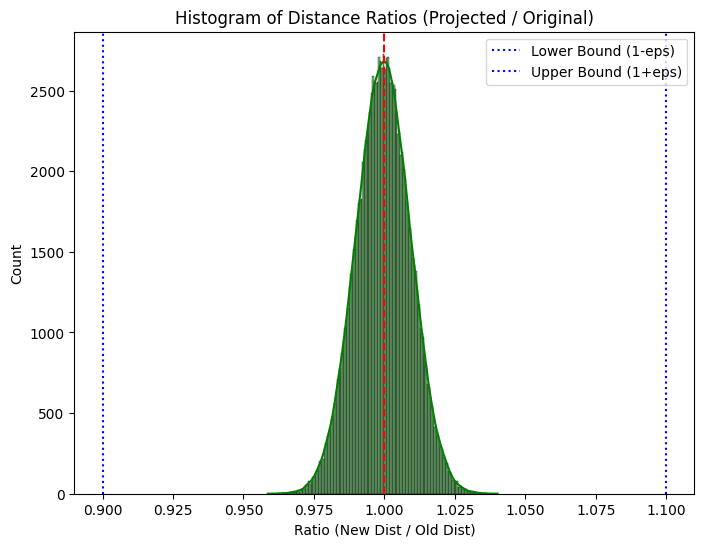

In [ ]:
from sklearn.random_projection import GaussianRandomProjection, SparseRandomProjection, johnson_lindenstrauss_min_dim
from sklearn.metrics.pairwise import euclidean_distances
import seaborn as sns

# 1. Determine necessary components for a given error
n_samples = 500
epsilon = 0.1 # Allow 10% distortion

min_dim = johnson_lindenstrauss_min_dim(n_samples=n_samples, eps=epsilon)
print(f"To preserve pairwise distances of {n_samples} samples with {epsilon*100}% max error,")
print(f"we need at least {min_dim} dimensions.")

# 2. Generate synthetic high-dimensional data
d_original = 50000
X = np.random.rand(n_samples, d_original)

# 3. Apply Random Projection
# We project from 50000 dimensions down to 'min_dim' 
transformer = SparseRandomProjection(n_components=min_dim, random_state=42)
X_new = transformer.fit_transform(X)

print(f"Original shape: {X.shape}")
print(f"Projected shape: {X_new.shape}")

# 4. Verify Distance Preservation
# Compute pairwise distances in original space
dist_original = euclidean_distances(X)
# Extract upper triangle (unique pairs), excluding diagonal
original_dists = dist_original[np.triu_indices(n_samples, k=1)]

# Compute pairwise distances in projected space
dist_new = euclidean_distances(X_new)
new_dists = dist_new[np.triu_indices(n_samples, k=1)]

# Calculate the ratio of new distances to old distances
ratios = new_dists / original_dists

# Plotting
plt.figure(figsize=(8, 6))
sns.histplot(ratios, kde=True, color='green')
plt.axvline(1.0, color='red', linestyle='--')
plt.axvline(1 - epsilon, color='blue', linestyle=':', label='Lower Bound (1-eps)')
plt.axvline(1 + epsilon, color='blue', linestyle=':', label='Upper Bound (1+eps)')
plt.title("Histogram of Distance Ratios (Projected / Original)")
plt.xlabel("Ratio (New Dist / Old Dist)")
plt.legend()
plt.show()


### Interpretation of the Plot

If the JL Lemma holds, the histogram of ratios should cluster tightly around **1.0**.

* Most pairs should have a ratio between $0.9$ and $1.1$ (for $\epsilon=0.1$).
* This confirms that although we threw away thousands of dimensions, the **relative geometry** of the data points remains intact.

### When to use Random Projection?

* When the number of features is very large (e.g., text data, genomic data, images).
* When PCA is too slow to compute.
* As a preprocessing step before clustering (K-Means) or classification in high-dim space.

### References

1.  Blum, A., Hopcroft, J., & Kannan, R. (2020). *Foundations of Data Science*. Cambridge University Press. (Chapter 2).
2.  Scikit-Learn Documentation: [Random Projection](https://scikit-learn.org/stable/modules/random_projection.html).
3.  Achlioptas, D. (2003). *Database-friendly random projections: Johnson-Lindenstrauss with binary coins*.
4. Saeed, Mehreen. [Random Projection: Theory and Implementation in Python with Scikit-Learn](https://stackabuse.com/random-projection-theory-and-implementation-in-python-with-scikit-learn/)